# Forced Oscillation Source Localization

Forced oscillations in power systems arise when a periodic disturbance, such
as a malfunctioning governor valve, injects energy at a fixed frequency.
Unlike natural oscillations, forced oscillations persist as long as the source
remains active, and resonance can amplify the response at generators far from
the source. Locating the source from measurements alone is therefore a
non-trivial problem.

This notebook demonstrates two PMU-based methods on a 179-bus WECC system
with 29 generators:

1. **Energy flow analysis**: the dissipating energy flow (DEF) method
   computes $E_i = \int \Delta P_{e,i} \cdot \Delta\omega_i\, dt$ at each
   generator; the source is the only generator with a positive value
   [1, 2].
2. **Phase difference analysis**: the $P_e$–$\omega$ phase difference at the
   source is a clear outlier relative to all other generators [2].

Both methods use only bus frequency and electrical power, quantities directly
observable from phasor measurement units.

**References**

[1] S. Maslennikov, B. Wang, and E. Litvinov,
"Dissipating energy flow method for locating the source of sustained
oscillations," *Int. J. Elect. Power Energy Syst.*, vol. 88, pp. 55–62,
Jun. 2017.

[2] L. Chen, Y. Min, and W. Hu,
"An energy-based method for location of power system oscillation source,"
*IEEE Trans. Power Syst.*, vol. 28, no. 2, pp. 828–836, May 2013.

In [1]:
%matplotlib inline

import numpy as np
from scipy import signal
from pathlib import Path
from matplotlib import pyplot as plt

import andes

andes.config_logger(stream_level=30)

## System Setup

The WECC 179-bus system is loaded from PSS/E format files originally provided
by Kai Sun's
[Oscillation Test Cases Library](https://web.eecs.utk.edu/~kaisun/Oscillation/).
The model contains 29 GENCLS generators with uniform damping ($D = 4$).
A TGOV1 governor is added to each generator to provide realistic mechanical
power dynamics, and BusFreq devices are installed at all generator buses.

In [2]:
case_dir = Path("cases/wecc179")
ss = andes.load(str(case_dir / "wecc179.raw"),
                addfile=str(case_dir / "wecc179.dyr"), setup=False)

gen_buses = list(ss.GENCLS.bus.v)
gen_idxs = list(ss.GENCLS.idx.v)
n_gen = len(gen_idxs)

for idx in gen_idxs:
    ss.add("TGOV1", syn=idx, R=0.05, T1=0.5, T2=1.0,
           T3=2.0, Dt=0.0, VMAX=99, VMIN=0)

for bus in gen_buses:
    ss.add("BusFreq", bus=bus)

ss.setup()
ss.PFlow.run()

True

## Periodic Disturbance Injection

A square-wave disturbance at 0.37 Hz is applied to the auxiliary power input
of the generator at bus 77. This frequency coincides with a natural
electromechanical mode of the system, producing resonance. Due to resonance,
generators far from the source may oscillate with comparable or even larger
amplitude, making amplitude-based source identification unreliable.

In [3]:
source_bus = 77
source_idx = dict(zip(gen_buses, gen_idxs))[source_bus]

f_osc = 0.37
half_period = 1.0 / (2 * f_osc)
amplitude = 0.03
t_start, t_end = 2.0, 42.0

ss.config.warn_abnormal = 0
ss.TDS.config.tf = t_start
ss.TDS.config.no_tqdm = 1
ss.TDS.run()

t = t_start
positive = True
while t + half_period <= t_end:
    ss.SynGen.set_paux(ss, source_idx, amplitude if positive else -amplitude)
    t += half_period
    ss.TDS.config.tf = t
    ss.TDS.run()
    positive = not positive

ss.SynGen.set_paux(ss, source_idx, 0.0)
ss.TDS.config.tf = t_end + 5.0
ss.TDS.run()

True

## Observing the Forced Oscillation

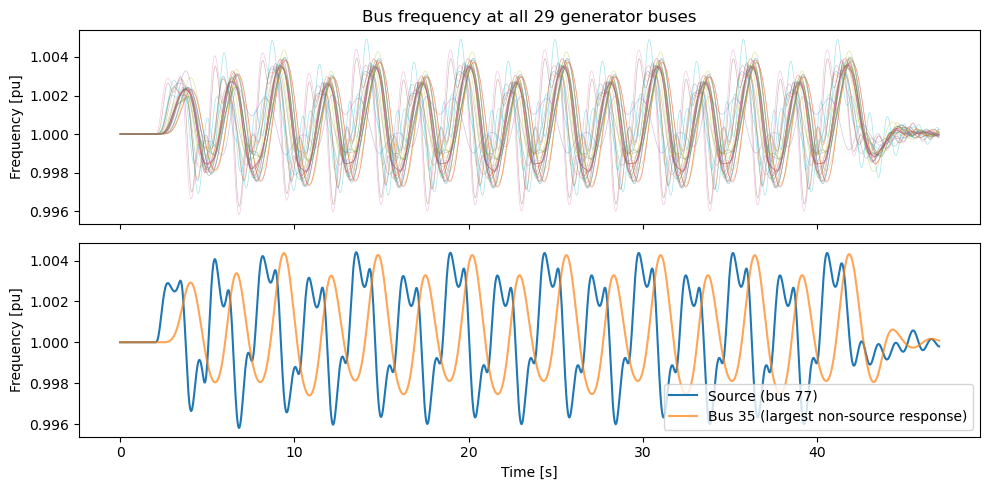

In [4]:
ts_bf = ss.TDS.get_timeseries(ss.BusFreq.f)
bf_buses = list(ss.BusFreq.bus.v)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for i in range(len(bf_buses)):
    axes[0].plot(ts_bf.index, ts_bf.iloc[:, i], alpha=0.4, linewidth=0.5)
axes[0].set_ylabel("Frequency [pu]")
axes[0].set_title("Bus frequency at all 29 generator buses")

source_col = bf_buses.index(source_bus)
remote_col = bf_buses.index(35)

axes[1].plot(ts_bf.index, ts_bf.iloc[:, source_col],
             label=f"Source (bus {source_bus})")
axes[1].plot(ts_bf.index, ts_bf.iloc[:, remote_col],
             label="Bus 35 (largest non-source response)", alpha=0.7)
axes[1].set_ylabel("Frequency [pu]")
axes[1].set_xlabel("Time [s]")
axes[1].legend()

plt.tight_layout()

All 29 generator buses exhibit oscillations at the forcing frequency.
The amplitude at bus 35 exceeds that at the source (bus 77), illustrating the
resonance amplification effect. This behavior renders simple amplitude
comparison unreliable for source identification and motivates the energy-based
and phase-based methods developed below.

## Spectral Analysis

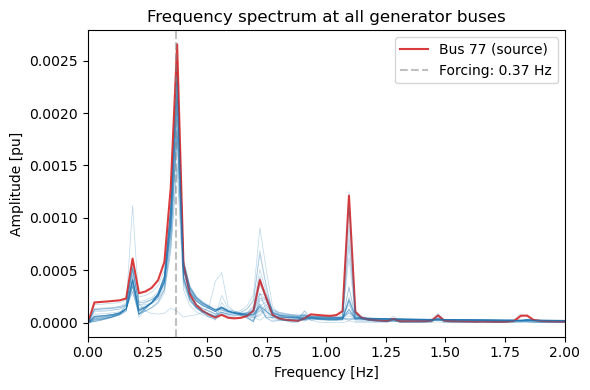

In [12]:
time = ts_bf.index.values
mask = (time >= 5.0) & (time <= t_end)
t_ss = time[mask]
dt = np.median(np.diff(t_ss))
N = len(t_ss)

bf_ss = ts_bf.loc[mask].values
freqs = np.fft.rfftfreq(N, d=dt)

fig, ax = plt.subplots(figsize=(6, 4))
for i, bus in enumerate(bf_buses):
    spectrum = np.abs(np.fft.rfft(bf_ss[:, i] - bf_ss[:, i].mean())) * 2 / N
    is_src = bus == source_bus
    ax.plot(freqs, spectrum,
            alpha=0.9 if is_src else 0.3,
            linewidth=1.5 if is_src else 0.5,
            color="#d62728" if is_src else "#1f77b4",
            label=f"Bus {bus} (source)" if is_src else None)

ax.set_xlim(0, 2.0)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Amplitude [pu]")
ax.set_title("Frequency spectrum at all generator buses")
ax.axvline(f_osc, color="gray", linestyle="--", alpha=0.5,
           label=f"Forcing: {f_osc} Hz")
ax.legend()
plt.tight_layout()

A sharp spectral peak at 0.37 Hz is present at all generator buses, confirming
the forced oscillation frequency. The peak amplitudes are comparable across
buses, reinforcing the observation that amplitude alone cannot identify the
source.

## Energy-Based Source Localization

The oscillation energy flow at each generator is computed as

$$E_i = \int \Delta P_{e,i}(t) \cdot \Delta\omega_i(t)\, dt$$

where $\Delta P_{e,i}$ and $\Delta\omega_i$ are bandpass-filtered oscillatory
components of electrical power and rotor speed. A generator that injects
oscillation energy into the network (the source) yields a positive value,
while generators that absorb energy yield negative values.

In [6]:
ts_Pe = ss.TDS.get_timeseries(ss.GENCLS.Pe)
ts_omega = ss.TDS.get_timeseries(ss.GENCLS.omega)

Pe_ss = ts_Pe.loc[mask].values
omega_ss = ts_omega.loc[mask].values

fs = 1.0 / dt
sos = signal.butter(4, [max(f_osc - 0.1, 0.05), f_osc + 0.1],
                    btype="bandpass", fs=fs, output="sos")

energy = np.zeros(n_gen)
for j in range(n_gen):
    pe_filt = signal.sosfiltfilt(sos, Pe_ss[:, j])
    om_filt = signal.sosfiltfilt(sos, omega_ss[:, j] - 1.0)
    energy[j] = np.trapezoid(pe_filt * om_filt, t_ss)


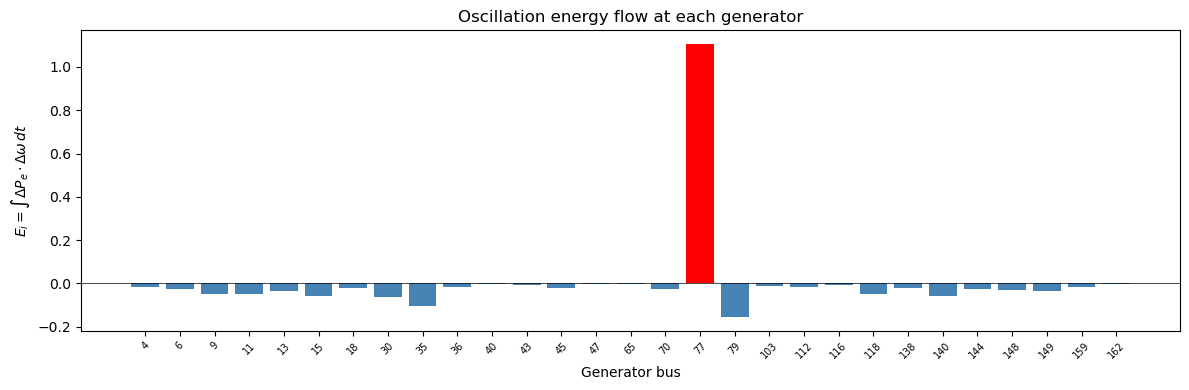

In [7]:

bus_labels = [str(b) for b in gen_buses]
colors = ["red" if b == source_bus else "steelblue" for b in gen_buses]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(bus_labels, energy, color=colors)
ax.set_xlabel("Generator bus")
ax.set_ylabel(r"$E_i = \int \Delta P_e \cdot \Delta\omega\, dt$")
ax.set_title("Oscillation energy flow at each generator")
ax.axhline(0, color="black", linewidth=0.5)
plt.xticks(rotation=45, fontsize=7)
plt.tight_layout()

The source generator at bus 77 (red) is the only generator with a positive
energy flow, indicating that it injects oscillation energy into the network.
All remaining 28 generators have negative values, meaning they absorb energy
from the oscillation. The margin is decisive: the source energy exceeds +1.1,
while the next-closest generator is near zero.

## Phase-Based Confirmation

The phase difference between electrical power and rotor speed oscillations
at the forcing frequency provides an independent confirmation of the source
location. At the source, the $P_e$–$\omega$ phase difference deviates
substantially from the cluster formed by all other generators.

In [8]:
f_idx = np.argmin(np.abs(freqs - f_osc))

phase_diff = np.zeros(n_gen)
for j in range(n_gen):
    fft_pe = np.fft.rfft(Pe_ss[:, j] - Pe_ss[:, j].mean())
    fft_om = np.fft.rfft(omega_ss[:, j] - omega_ss[:, j].mean())
    diff = np.angle(fft_pe[f_idx]) - np.angle(fft_om[f_idx])
    phase_diff[j] = np.degrees(np.arctan2(np.sin(diff), np.cos(diff)))


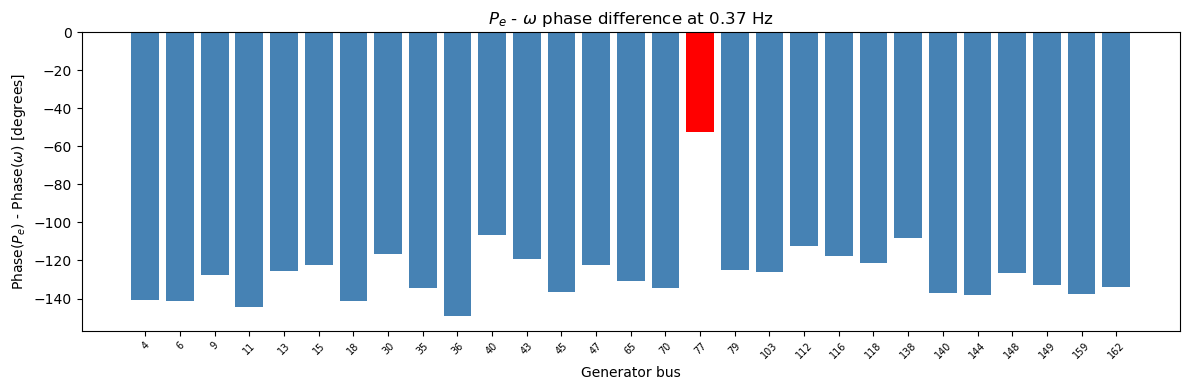

In [9]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(bus_labels, phase_diff, color=colors)
ax.set_xlabel("Generator bus")
ax.set_ylabel("Phase($P_e$) - Phase($\\omega$) [degrees]")
ax.set_title(f"$P_e$ - $\\omega$ phase difference at {f_osc} Hz")
plt.xticks(rotation=45, fontsize=7)
plt.tight_layout()

The source generator at bus 77 exhibits a $P_e$–$\omega$ phase difference of
approximately $-52°$, while all other generators cluster between $-107°$ and
$-149°$. This distinct outlier position provides unambiguous identification of
the source, independent of and consistent with the energy flow result.

## Extend This Example

- **Change the forcing frequency** away from resonance and observe how the
  energy flow margins change.
- **Relocate the source** to a different generator and verify that both
  methods correctly identify the new location.
- **Add measurement noise** to test robustness under realistic PMU conditions.
- **Apply to field PMU data** from actual forced oscillation events documented
  in Kai Sun's
  [Oscillation Test Cases Library](https://web.eecs.utk.edu/~kaisun/Oscillation/).
  

In [10]:
!andes misc -C

"/home/hcui9/repos/andes/docs/source/gallery/wecc179_out.lst" removed.
"/home/hcui9/repos/andes/docs/source/gallery/wecc179_out.npz" removed.
"/home/hcui9/repos/andes/docs/source/gallery/wecc179_out.txt" removed.
